## Testing for convergence of differential elastic cross sections with channel radius using realistic $NA$ interaction

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Latex, Math, display
from periodictable import elements

In [2]:
from matplotlib import pyplot as plt

In [3]:
from tqdm import tqdm

import jitr

## set up system

In [4]:
A, Z = (208, 82)

In [5]:
name_core = str(elements[Z].symbol)
display(Math(f"^{{{A}}} \\rm{{{name_core}}}"))

<IPython.core.display.Math object>

In [6]:
neutron = (1, 0)
proton = (1, 1)
projectile = proton
target = (A, Z)

## Grab samples

In [7]:
# we have 416 samples from the KDUQ posterior
kduq_omp_samples = jitr.optical_potentials.kduq.get_samples_democratic(projectile)

## Set up solvers

In [8]:
lab_energy_grid = np.array([10, 60, 100])
range_fm = jitr.utils.interaction_range(A)
print(range_fm)

7.109990564177688


In [9]:
angles = np.linspace(0.01,np.pi,180)

In [10]:
channel_radii = np.arange(10, 50, 4)
channel_radii

array([10, 14, 18, 22, 26, 30, 34, 38, 42, 46])

In [11]:
reaction = jitr.reactions.Reaction(target=target, projectile=projectile, process="EL")

In [12]:
def set_up_grid(core, lab_energy_grid):
    solvers = []
    for i, Elab in enumerate(tqdm(lab_energy_grid)):
        kinematics = reaction.kinematics(Elab)
        solvers.append([])
        for channel_radius in channel_radii:
            N = jitr.utils.suggested_basis_size(channel_radius*kinematics.k)
            lmax = int(max(30,kinematics.k * range_fm) )
            solvers[-1].append(
                jitr.xs.elastic.DifferentialWorkspace.build_from_system(
                    reaction=reaction,
                    kinematics=kinematics,
                    angles=angles,
                    channel_radius_fm=channel_radius,
                    solver=jitr.rmatrix.Solver(N),
                    lmax=lmax,
                    smatrix_abs_tol=0,
                )
            )
    return solvers

In [13]:
solvers = set_up_grid(target, lab_energy_grid)

100%|██████████| 3/3 [03:23<00:00, 67.79s/it]


## Run calculations

In [14]:
N = 10  # number of samples to draw from each posterior
draws_kduq = np.random.choice(len(kduq_omp_samples), size=N)

In [15]:
xs = np.zeros((N,lab_energy_grid.size, channel_radii.size,  angles.size))
for i, sample in enumerate(tqdm(kduq_omp_samples[draws_kduq, :])):

    for j, Ecm in enumerate(lab_energy_grid):
        for k, channel_radius in enumerate(channel_radii):

            coulomb_params, scalar_params, spin_orbit_params = (
                jitr.optical_potentials.kduq.calculate_params(
                    projectile, target, solvers[j][k].kinematics.Elab, *sample
                )
            )

            x = solvers[j][k].xs(
                jitr.optical_potentials.kduq.central_plus_coulomb,
                jitr.optical_potentials.kduq.spin_orbit,
                (scalar_params, coulomb_params),
                spin_orbit_params,
            )
            if projectile == proton:
                x.dsdo /= solvers[j][k].rutherford
            xs[i,j,k,:] = x.dsdo


100%|██████████| 10/10 [00:15<00:00,  1.50s/it]


In [16]:
xs = np.median(xs, axis=0)

## Visualize results

In [17]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [19]:
Eidx = 0
print(f"Plots for E = {lab_energy_grid[Eidx]} MeV")

Plots for E = 10 MeV


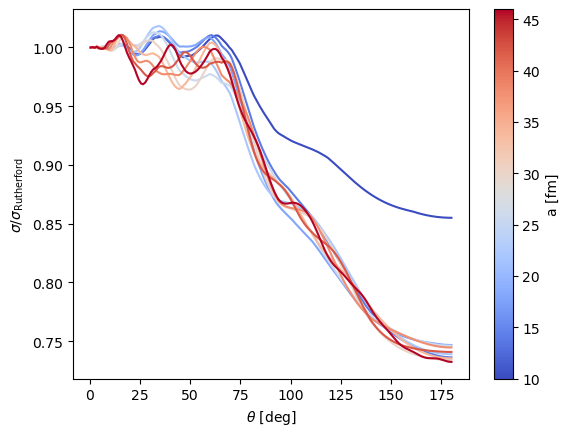

In [20]:
cmap = plt.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=min(channel_radii), vmax=max(channel_radii))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) # 'Fake' the array as the colors are used in the loop

for i in range(len(channel_radii)):
    a = channel_radii[i]
    color = sm.to_rgba(a)
    plt.plot(angles*180/np.pi, xs[Eidx,i,:], color=color, label=f"a={a} fm")
#plt.legend()
plt.gcf().colorbar(sm, ax=plt.gca(), label='a [fm]')
plt.xlabel(r"$\theta$ [deg]")


if projectile == neutron:
    plt.yscale("log")    
    plt.ylabel(r"$\frac{d\sigma}{d\Omega}$ [mb/Sr]")
else:
    plt.ylabel(r"$\sigma / \sigma_{\text{Rutherford}}$")


Text(0, 0.5, 'relative difference in $\\frac{d\\sigma}{d\\Omega}$ [%]')

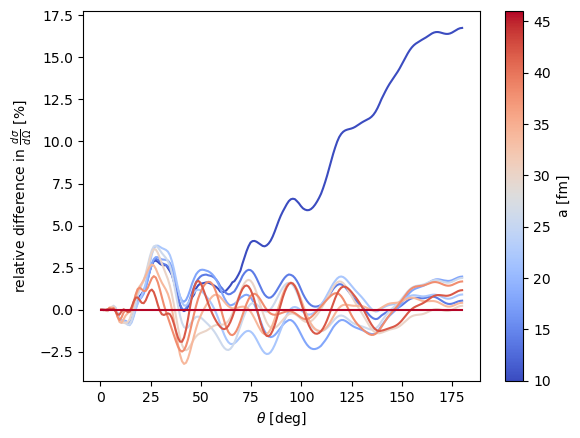

In [24]:
for i in range(len(channel_radii)):
    a = channel_radii[i]
    color = sm.to_rgba(a)
    rel_diff = (xs[Eidx,i,:] - xs[Eidx,-1,:]) / xs[Eidx,-1,:] * 100
    plt.plot(angles*180/np.pi, rel_diff, color=color, label=f"a={a} fm")
#plt.yscale("log")
#plt.legend()
plt.gcf().colorbar(sm, ax=plt.gca(), label='a [fm]')
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"relative difference in $\frac{d\sigma}{d\Omega}$ [%]")
#plt.ylim([-100,100])

/tmp/local/2442019/ipykernel_293013/4151910858.py:4: RuntimeWarning: divide by zero encountered in log
  diff = np.log( np.abs(xs[Eidx,i,:] - xs[Eidx,-1,:]))


Text(0, 0.5, 'log absolute difference in $\\frac{d\\sigma}{d\\Omega}$')

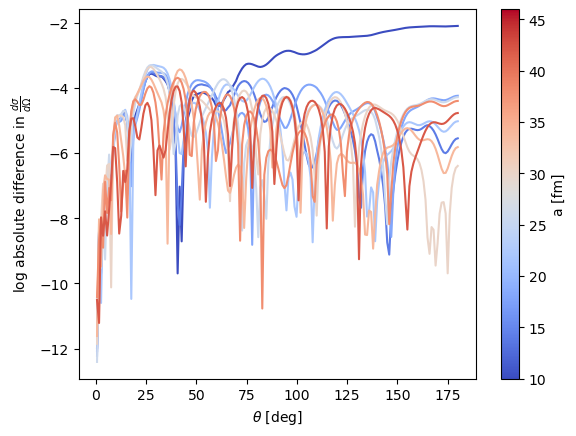

In [22]:
for i in range(len(channel_radii)):
    a = channel_radii[i]
    color = sm.to_rgba(a)
    diff = np.log( np.abs(xs[Eidx,i,:] - xs[Eidx,-1,:]))
    plt.plot(angles*180/np.pi, diff, color=color, label=f"a={a} fm")
#plt.yscale("log")
#plt.legend()
plt.gcf().colorbar(sm, ax=plt.gca(), label='a [fm]')
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"log absolute difference in $\frac{d\sigma}{d\Omega}$")
#plt.ylim([-10,10])

/tmp/local/2442019/ipykernel_293013/2888872556.py:8: RuntimeWarning: divide by zero encountered in log
  cum_log_diff[i] = np.sum(np.log( np.abs(xs[Eidx,i,:] - xs[Eidx,-1,:])))


Text(0, 0.5, 'cum log absdiff')

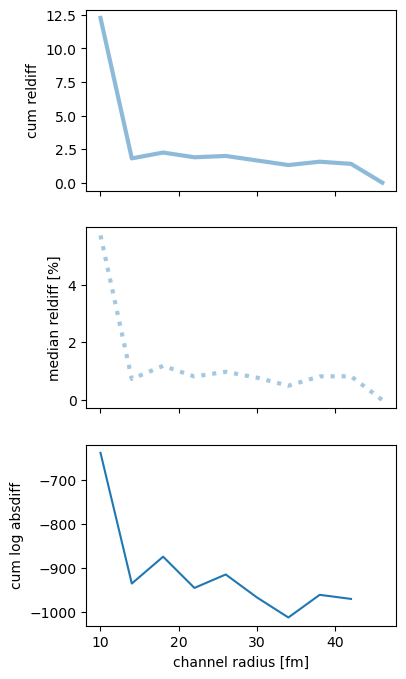

In [23]:
cum_diff = np.zeros_like(channel_radii, dtype=float)
cum_log_diff = np.zeros_like(channel_radii, dtype=float)
median_diff = np.zeros_like(channel_radii, dtype=float)
for i in range(len(channel_radii)):
    a = channel_radii[i]
    color = sm.to_rgba(a)
    cum_diff[i] = np.sum(np.abs(xs[Eidx,i,:] - xs[Eidx,-1,:]) / xs[Eidx,-1,:])
    cum_log_diff[i] = np.sum(np.log( np.abs(xs[Eidx,i,:] - xs[Eidx,-1,:])))
    median_diff[i] = 100*np.median(np.abs(xs[Eidx,i,:] - xs[Eidx,-1,:]) / xs[Eidx,-1,:])

fig, axes=  plt.subplots(3,1, sharex=True, figsize=(4,8))
axes[0].plot(channel_radii, cum_diff, label="cumulative relative difference", alpha=0.5, linewidth=3)
axes[1].plot(channel_radii, median_diff,":", label="median relative difference", alpha=0.4, linewidth=3)
axes[2].plot(channel_radii, cum_log_diff, label="cumulative log absolute difference")

axes[-1].set_xlabel("channel radius [fm]")

axes[0].set_ylabel("cum reldiff")
axes[1].set_ylabel("median reldiff [%]")
axes[2].set_ylabel("cum log absdiff")